In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

## Exercise 2.1. Exercise 1

### 1. Read and display the image.
- Read the image using the Pillow library and display it.
- You can also use matplotlib to display the image.

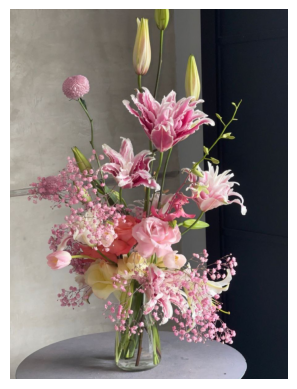

In [6]:
# Read image
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/flo.jpg")

# Convert to numpy array
img_array = np.array(img)

# Display image
plt.imshow(img_array)
plt.axis("off")
plt.show()

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Display only the top left corner of 100x100 pixels.
- Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.

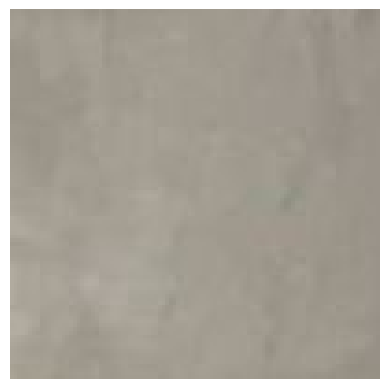

In [7]:
# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

# Display
plt.imshow(top_left)
plt.axis("off")
plt.show()

### 3. Show the three color channels (R, G, B).
- Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

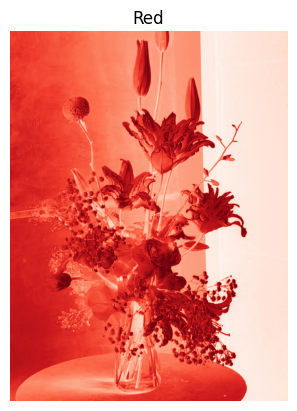

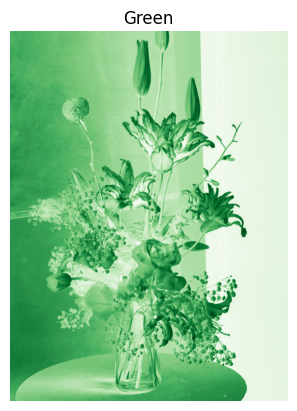

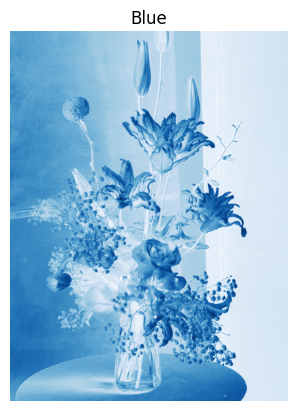

In [8]:
# Extract channels
red = img_array[:,:,0]
green = img_array[:,:,1]
blue = img_array[:,:,2]

plt.imshow(red, cmap='Reds')
plt.title("Red")
plt.axis("off")
plt.show()

plt.imshow(green, cmap='Greens')
plt.title("Green")
plt.axis("off")
plt.show()

plt.imshow(blue, cmap='Blues')
plt.title("Blue")
plt.axis("off")
plt.show()


### 4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
- Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

In [9]:
# Make a copy of the image
modified_img = img_array.copy()

# Change top-left 100x100 pixels
modified_img[0:100, 0:100] = 210

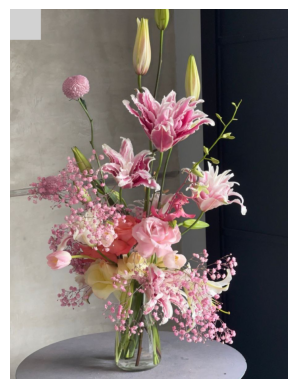

In [10]:
plt.imshow(modified_img)
plt.axis("off")
plt.show()

## Exercise 2.2. Exercise 2

### 1. Load and display a grayscale image.
- Load a grayscale image using the Pillow library.
- Display the grayscale image using matplotlib.

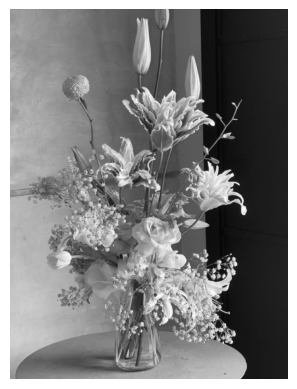

In [12]:
# Load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/flo.jpg").convert("L")

# Convert to numpy array
img_array = np.array(img)

# Display grayscale image
plt.imshow(img_array, cmap='gray')
plt.axis("off")
plt.show()

### 2. Extract and display the middle section of the image (150 pixels).
- Extract a 150 pixel section from the center of the image using NumPy array slicing.
- Display this cropped image using matplotlib.

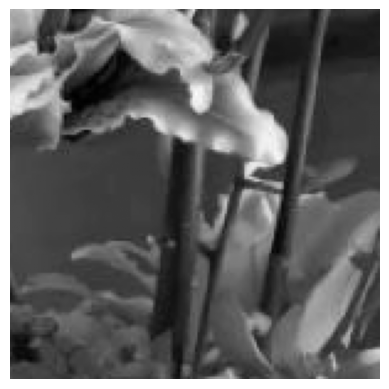

In [13]:
h, w = img_array.shape

# Gives center coordinates
center_x = w // 2
center_y = h // 2

# Crop 150x150 region
middle_section = img_array[center_y-75:center_y+75, center_x-75:center_x+75]

plt.imshow(middle_section, cmap='gray')
plt.axis("off")
plt.show()

### 3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
- Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
- Display the resulting binary image.

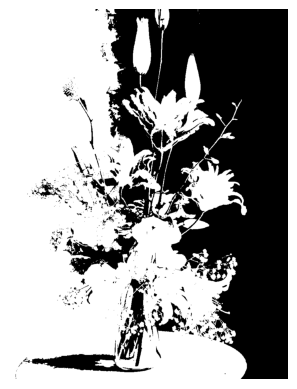

In [14]:
binary_img = img_array.copy()

# Apply threshold
binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

plt.imshow(binary_img, cmap='gray')
plt.axis("off")
plt.show()

### 4. Rotate the image 90 degrees clockwise and display the result.
- Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
- Display the rotated image using matplotlib.

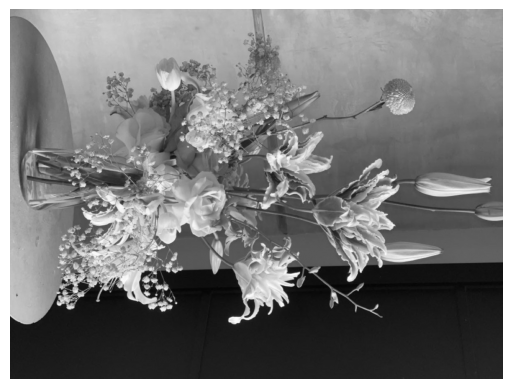

In [15]:
rotated_img = np.rot90(img_array, k=-1)

plt.imshow(rotated_img, cmap='gray')
plt.axis("off")
plt.show()

### 5. Convert the grayscale image to an RGB image.
- Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
- Display the converted RGB image using matplotlib.

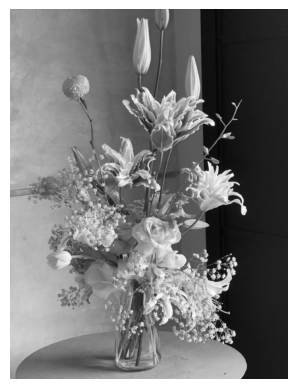

In [16]:
# Load grayscale image
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/flo.jpg").convert("L")
img_array = np.array(img)

# Convert grayscale to RGB
rgb_array = np.stack((img_array, img_array, img_array), axis=-1)

plt.imshow(rgb_array)
plt.axis("off")
plt.show()

## 3. Image Compression and Decompression using PCA.

### 1. Load and Prepare Data:
- Fetch an image of you choice.{If colour convert to grayscale}
- Center the dataset - Standaridze the Data.
- Calculate the covaraince matrix of the Standaridze data.

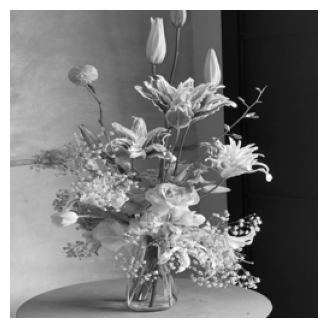

Image shape: (256, 256)


In [17]:
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/flo.jpg").convert("L")
img = img.resize((256, 256))
img_array = np.array(img, dtype=float)

plt.figure(figsize=(4, 4))
plt.imshow(img_array, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

print(f"Image shape: {img_array.shape}")

In [18]:
mean_vec = np.mean(img_array, axis=0)
std_vec  = np.std(img_array,  axis=0) + 1e-8
X_std    = (img_array - mean_vec) / std_vec

cov_matrix = (X_std.T @ X_std) / (img_array.shape[0] - 1)

print(f"Mean vector shape   : {mean_vec.shape}")
print(f"Standardized shape  : {X_std.shape}")
print(f"Covariance matrix   : {cov_matrix.shape}")

Mean vector shape   : (256,)
Standardized shape  : (256, 256)
Covariance matrix   : (256, 256)


In [19]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Eigenvalues  shape: {eigenvalues.shape}")
print(f"Eigenvectors shape: {eigenvectors.shape}")
print(f"\nTop 10 eigenvalues: {eigenvalues[:10].round(2)}")

Eigenvalues  shape: (256,)
Eigenvectors shape: (256, 256)

Top 10 eigenvalues: [61.63 49.22 23.08 16.51 13.05  9.44  7.04  6.7   5.88  4.82]


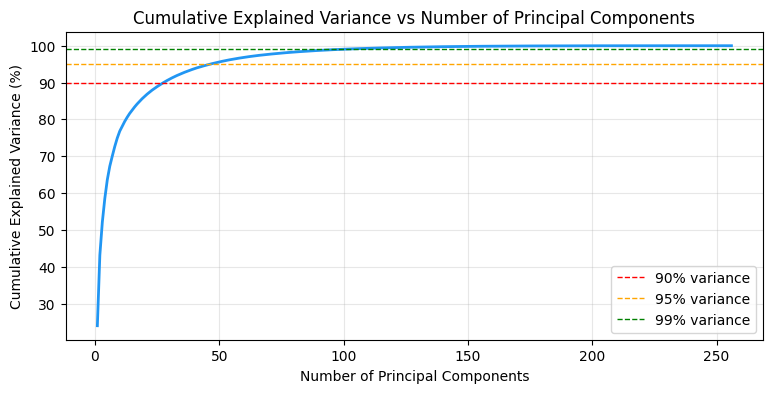

90% variance → 28 components
95% variance → 47 components
99% variance → 99 components


In [20]:
total_var     = np.sum(eigenvalues)
explained     = eigenvalues / total_var
cum_explained = np.cumsum(explained)

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(cum_explained) + 1), cum_explained * 100, color="#2196F3", linewidth=2)
plt.axhline(90, color="red",    linestyle="--", linewidth=1, label="90% variance")
plt.axhline(95, color="orange", linestyle="--", linewidth=1, label="95% variance")
plt.axhline(99, color="green",  linestyle="--", linewidth=1, label="99% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance vs Number of Principal Components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for thresh in [0.90, 0.95, 0.99]:
    k = int(np.searchsorted(cum_explained, thresh)) + 1
    print(f"{thresh*100:.0f}% variance → {k} components")

In [21]:
def reconstruct(X_std, eigvecs, mean_vec, std_vec, k):
    PC_k    = eigvecs[:, :k]
    scores  = X_std @ PC_k
    X_recon = scores @ PC_k.T
    img_recon = X_recon * std_vec + mean_vec
    return np.clip(img_recon, 0, 255)

test_recon = reconstruct(X_std, eigenvectors, mean_vec, std_vec, 50)
print(f"Reconstructed image shape: {test_recon.shape}")

Reconstructed image shape: (256, 256)


In [22]:
k_values = [10, 20, 50, 100, 150]
reconstructions = {}

for k in k_values:
    reconstructions[k] = reconstruct(X_std, eigenvectors, mean_vec, std_vec, k)
    ev = cum_explained[k - 1] * 100
    print(f"k={k:>4d}  →  Cumulative Explained Variance = {ev:.2f}%")

k=  10  →  Cumulative Explained Variance = 76.80%
k=  20  →  Cumulative Explained Variance = 86.24%
k=  50  →  Cumulative Explained Variance = 95.59%
k= 100  →  Cumulative Explained Variance = 99.05%
k= 150  →  Cumulative Explained Variance = 99.82%


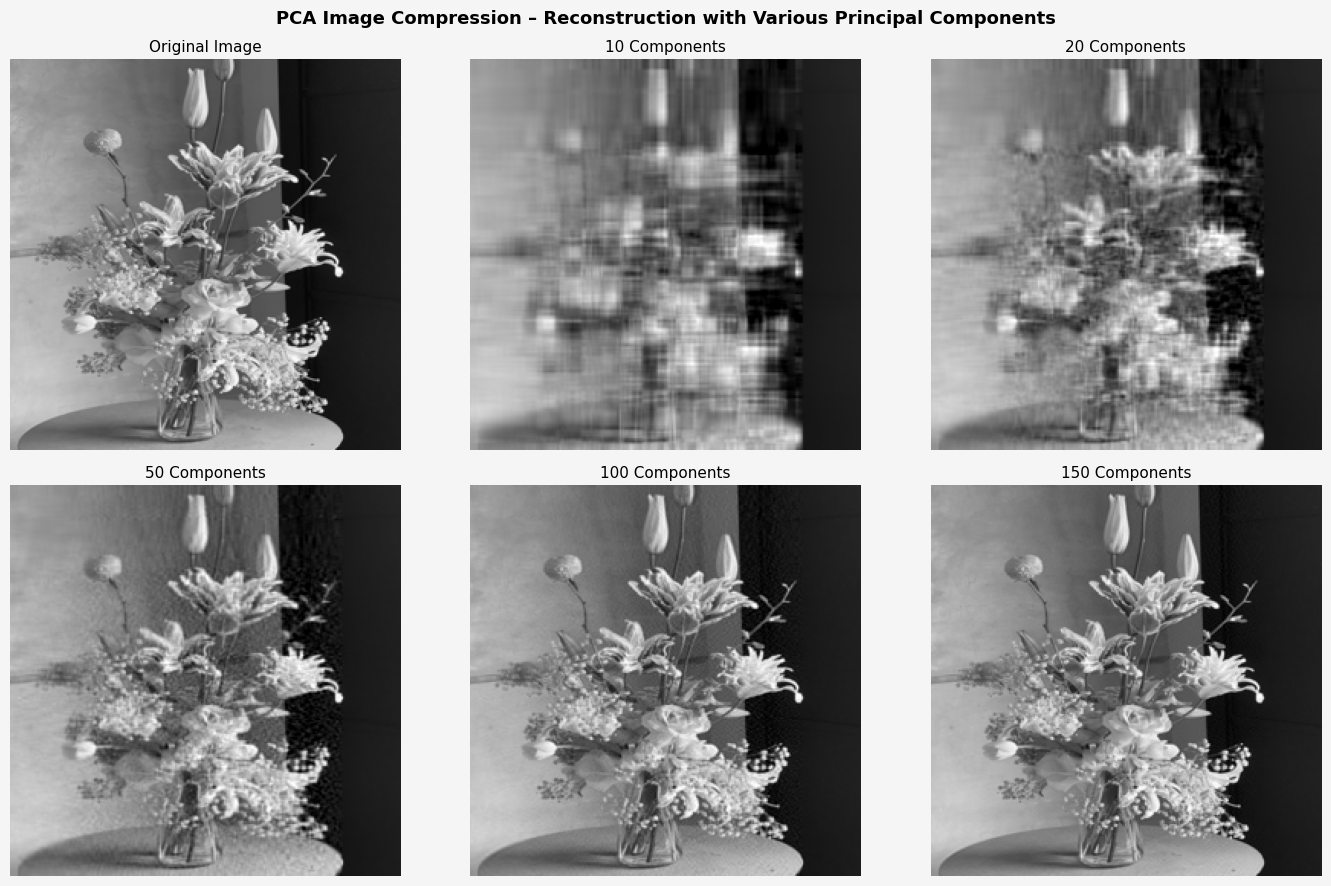

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.patch.set_facecolor("#f5f5f5")

panels = [("Original Image", img_array, None)] + \
         [(f"{k} Components", reconstructions[k], k)
          for k in k_values]

for ax, (title, data, k) in zip(axes.flat, panels):
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    if k is not None:
        mse  = np.mean((img_array - data) ** 2)
        psnr = 10 * np.log10(255**2 / mse)
        compression = (k * (img_array.shape[0] + img_array.shape[1])) / img_array.size * 100
        ax.set_xlabel(f"PSNR: {psnr:.1f} dB  |  Storage: {compression:.1f}%", fontsize=8)
        ax.xaxis.set_visible(True)
        ax.tick_params(bottom=False, labelbottom=True)

fig.suptitle("PCA Image Compression – Reconstruction with Various Principal Components",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()